# 06 — Dynamic-Graph iTransformer

## Architecture
- **iTransformer backbone** with inverted (feature-wise) attention
- **Dynamic Graph Convolution** layer that learns inter-feature adjacency dynamically
- Fuses local (graph) + global (attention) representations
- Built with TensorFlow/Keras

## Goal
Capture both long-range temporal dependencies and cross-feature correlations by combining graph neural network concepts with inverted Transformer attention.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from src.models.deep.itransformer import build_dynamic_graph_itransformer
from src.evaluation.metrics import regression_metrics, tolerance_accuracy
from src.utils.plotting import save_fig
from src.utils.config import (
    ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR,
    get_version_paths, ensure_version_dirs,
    WINDOW_SIZE, BATCH_SIZE, MAX_EPOCHS, EARLY_STOP_PATIENCE,
    TRANSFORMER_D_MODEL, TRANSFORMER_NHEAD, TRANSFORMER_LAYERS, DROPOUT,
)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")
plt.style.use("seaborn-v0_8-whitegrid")

# v2 paths
v2 = get_version_paths('v2')
ensure_version_dirs('v2')

TensorFlow: 2.20.0
GPUs: []


## 1. Load & Prepare Data

In [2]:
data = np.load(str(ARTIFACTS_DIR / "battery_sequences.npz"), allow_pickle=True)
X_multi = data["X_multi"]
y_multi = data["y_multi"]
bids = data["bids_multi"]

# -- v2: intra-battery chronological split --
# For each battery, first 80% of sequences -> train, last 20% -> test
train_idx, test_idx = [], []
for bid in np.unique(bids):
    idxs = np.where(bids == bid)[0]
    n = len(idxs)
    cut = int(0.8 * n)
    train_idx.extend(idxs[:cut].tolist())
    test_idx.extend(idxs[cut:].tolist())

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train, y_train = X_multi[train_idx], y_multi[train_idx]
X_test, y_test = X_multi[test_idx], y_multi[test_idx]

from sklearn.preprocessing import StandardScaler
n_samples, seq_len, n_feat = X_train.shape
scaler = StandardScaler().fit(X_train.reshape(-1, n_feat))
X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples, seq_len, n_feat)
X_test = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], seq_len, n_feat)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1444, 32, 12) | Test: (290, 32, 12)


## 2. Build Dynamic-Graph iTransformer

In [3]:
dg_model = build_dynamic_graph_itransformer(
    seq_len=seq_len, n_features=n_feat,
    d_model=TRANSFORMER_D_MODEL, n_heads=TRANSFORMER_NHEAD,
    n_blocks=TRANSFORMER_LAYERS, dropout=DROPOUT,
)
dg_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
dg_model.summary()
print(f"\nTotal parameters: {dg_model.count_params():,}")

Model: "DynamicGraph_iTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dyn_graph (DynamicGraphConv)    │ (None, 32, 12)         │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj (Dense)                    │ (None, 32, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_feat_0 (FeatureWiseMHA)      │ (None, 32, 64)         │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_token_0 (TokenWiseMHA)       │ (None, 32, 64)         │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_ff_0 (Conv1DFeedForward)     │ (None, 32, 64)         │        33,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_feat_1 (FeatureWiseMHA)      │ (None, 32, 64)         │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_token_1 (TokenWiseMHA)       │ (None, 32, 64)         │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_ff_1 (Conv1DFeedForward)     │ (None, 32, 64)         │        33,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,389 (493.71 KB)

 Trainable params: 126,389 (493.71 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 126,389


## 3. Train

In [4]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True, verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=10, verbose=1,
    ),
]

history = dg_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=1,
)

best_epoch = np.argmin(history.history["val_loss"]) + 1
print(f"\nBest epoch: {best_epoch}")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")

Epoch 1/150


 1/46 ━━━━━━━━━━━━━━━━━━━━ 3:51 5s/step - loss: 4102.9834 - mae: 59.6652

 4/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3990.3585 - mae: 58.0061

 7/46 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4055.2885 - mae: 59.0774

10/46 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4079.2131 - mae: 59.5288

...


Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 34.6863 - mae: 4.4971 - val_loss: 413.3799 - val_mae: 14.5803 - learning_rate: 5.0000e-04


Epoch 24: early stopping


Restoring model weights from the end of the best epoch: 4.



Best epoch: 4
Best val loss: 323.384186


## 4. Evaluate

In [5]:
y_pred = dg_model.predict(X_test, verbose=0).flatten()
metrics = regression_metrics(y_test, y_pred)
metrics["tol_2pct"] = tolerance_accuracy(y_test, y_pred, 2.0)
metrics["tol_5pct"] = tolerance_accuracy(y_test, y_pred, 5.0)

print("Dynamic-Graph iTransformer Results:")
print(f"  MAE  = {metrics['MAE']:.4f}")
print(f"  RMSE = {metrics['RMSE']:.4f}")
print(f"  R²   = {metrics['R2']:.4f}")
print(f"  MAPE = {metrics['MAPE']:.2f}%")
print(f"  Tol.Acc (±2%) = {metrics['tol_2pct']:.2%}")
print(f"  Tol.Acc (±5%) = {metrics['tol_5pct']:.2%}")

dg_model.save(str(v2["models_deep"] / "dynamic_graph_itransformer.keras"))
print("Model saved.")

Dynamic-Graph iTransformer Results:
  MAE  = 12.8865
  RMSE = 17.9829
  R²   = 0.1231
  MAPE = 69.98%
  Tol.Acc (±2%) = 4.83%
  Tol.Acc (±5%) = 28.97%
Model saved.


## 5. Training Curves

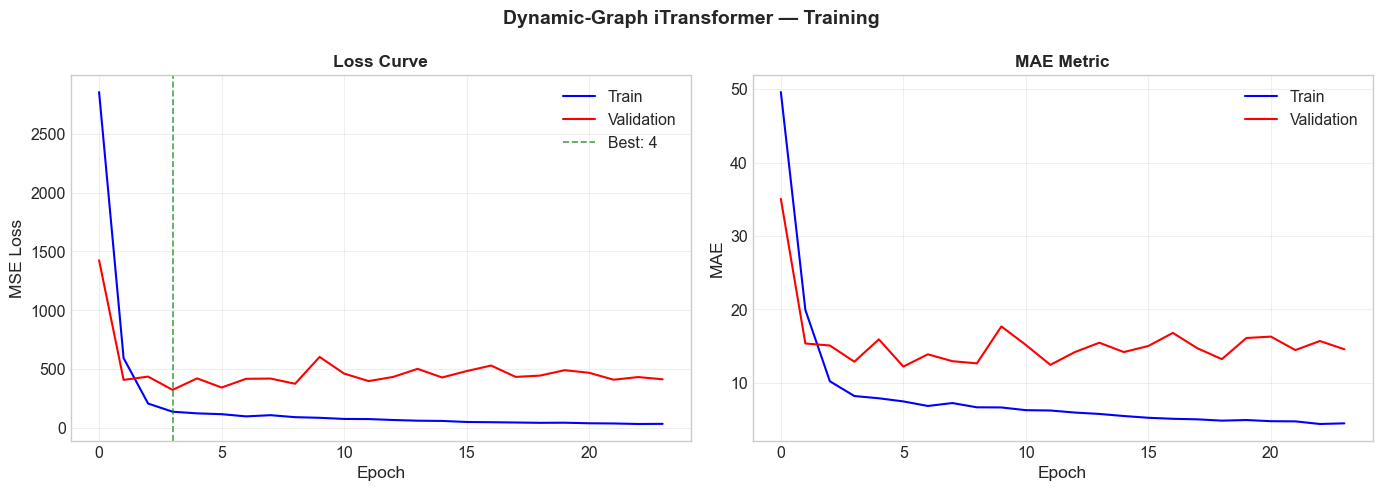

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history["loss"], "b-", linewidth=1.5, label="Train")
axes[0].plot(history.history["val_loss"], "r-", linewidth=1.5, label="Validation")
axes[0].axvline(x=best_epoch-1, color="green", linestyle="--", alpha=0.7, label=f"Best: {best_epoch}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curve", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# MAE
if "mae" in history.history:
    axes[1].plot(history.history["mae"], "b-", linewidth=1.5, label="Train")
    axes[1].plot(history.history["val_mae"], "r-", linewidth=1.5, label="Validation")
    axes[1].set_ylabel("MAE")
else:
    axes[1].plot(history.history["loss"], "b-", linewidth=1.5, label="Train Loss")
    axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_title("MAE Metric", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Dynamic-Graph iTransformer — Training", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig(fig, "v2_dg_itransformer_training"); plt.show()

## 6. Actual vs Predicted

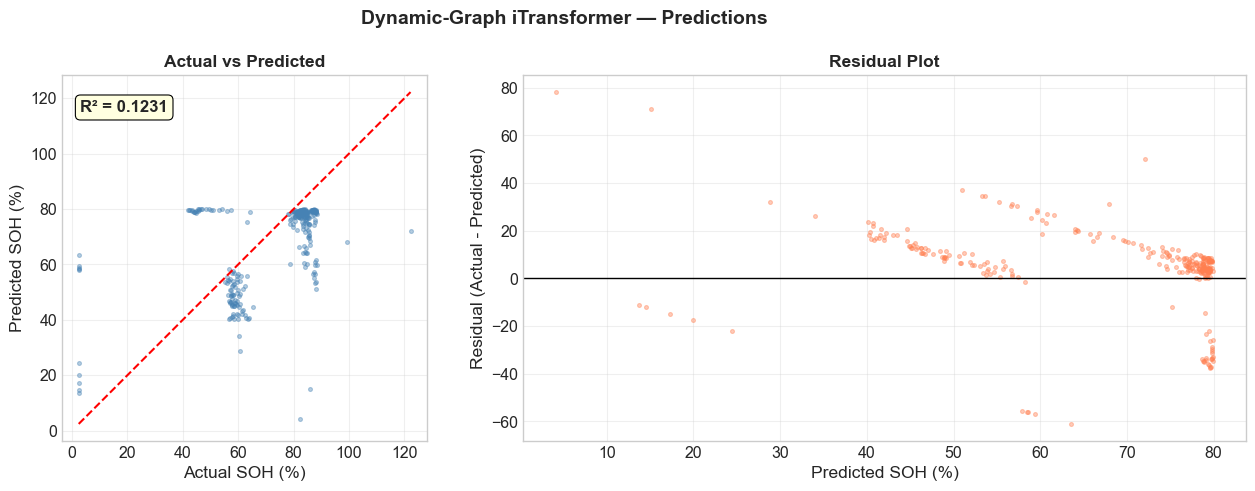

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, y_pred, s=8, alpha=0.4, c="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5)
axes[0].annotate(f"R² = {metrics['R2']:.4f}", xy=(0.05, 0.9), xycoords="axes fraction",
                 fontsize=12, fontweight="bold", bbox=dict(boxstyle="round", facecolor="lightyellow"))
axes[0].set_xlabel("Actual SOH (%)"); axes[0].set_ylabel("Predicted SOH (%)")
axes[0].set_title("Actual vs Predicted", fontweight="bold")
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, s=8, alpha=0.4, c="coral")
axes[1].axhline(y=0, color="black", linewidth=1)
axes[1].set_xlabel("Predicted SOH (%)"); axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot", fontweight="bold"); axes[1].grid(True, alpha=0.3)

plt.suptitle("Dynamic-Graph iTransformer — Predictions", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig(fig, "v2_dg_itransformer_predictions"); plt.show()

## 7. Learned Adjacency Matrix Visualization
Visualizing the learned inter-feature adjacency (if exposed by the model).

In [8]:
# Attempt to extract adjacency matrix from DynamicGraphConv layers
adj_found = False
for layer in dg_model.layers:
    if hasattr(layer, "adj"):
        adj = layer.adj.numpy()
        adj_found = True
        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(adj, cmap="viridis", aspect="auto")
        ax.set_xlabel("Feature j"); ax.set_ylabel("Feature i")
        ax.set_title("Learned Dynamic Adjacency Matrix", fontsize=13, fontweight="bold")
        plt.colorbar(im, ax=ax)
        save_fig(fig, "v2_dg_adjacency_matrix")
        plt.show()
        break

if not adj_found:
    print("Adjacency matrix not directly accessible; model uses softmax(QK^T) for dynamic graphs.")
    # Visualize attention weights instead
    print("Architecture relies on implicit feature correlations via attention.")

# Save metrics
import json
with open(v2["results"] / "v2_dg_itransformer_results.json", "w") as f:
    json.dump({k: float(v) for k, v in metrics.items()}, f, indent=2)
print("Results saved to artifacts/dg_itransformer_results.json")

Adjacency matrix not directly accessible; model uses softmax(QK^T) for dynamic graphs.
Architecture relies on implicit feature correlations via attention.
Results saved to artifacts/dg_itransformer_results.json
